# Titanic Dataset — Week 2: Predict Survival (Classification Model)
**Track:** Neurofive ML Track — Week 3
**Goal:** Train my first machine learning model — a Logistic Regression classifier that predicts whether a passenger survived.

This continues from the Week 1 (EDA) (cleaning + visualization) work, using the same dataset:
`https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv`


## 1. Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")


ModuleNotFoundError: No module named 'sklearn'

## 2. Load and clean the dataset (same approach as Week 2)

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df_clean = df.copy()

# Age: median per Pclass
df_clean['Age'] = df_clean.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked: mode
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Cabin: engineer a binary flag, then drop the original column
df_clean['has_cabin'] = df_clean['Cabin'].notnull().astype(int)
df_clean = df_clean.drop(columns=['Cabin'])

df_clean.isnull().sum()[df_clean.isnull().sum() > 0]  # should be empty


Series([], dtype: int64)

## 3. Feature selection and encoding

In [3]:
# Drop columns that aren't useful raw predictors for a first model:
# PassengerId (just an index), Name/Ticket (high-cardinality free text)
features = df_clean.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket'])
target = df_clean['Survived']

# One-hot encode categorical columns: Sex, Embarked
features_encoded = pd.get_dummies(features, columns=['Sex', 'Embarked'], drop_first=True)

features_encoded.head()


,Pclass,Age,SibSp,Parch,Fare,has_cabin,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,True,False,True
1,1,38.0,1,0,71.2833,1,False,False,False
2,3,26.0,0,0,7.9250,0,False,False,True
3,1,35.0,1,0,53.1000,1,False,False,True
4,3,35.0,0,0,8.0500,0,True,False,True


## 4. Train/test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42, stratify=target
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (712, 9)
Test shape: (179, 9)


## 5. Train the Logistic Regression model

In [5]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model trained.")


Model trained.


## 6. Evaluate: accuracy score

In [6]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


Accuracy: 0.8101 (81.01%)


## 7. Confusion matrix

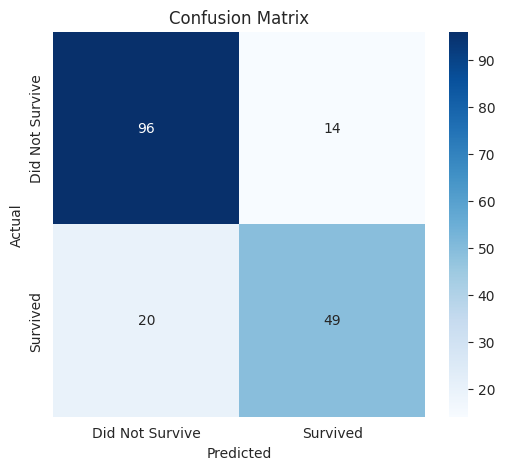

[[96 14]
 [20 49]]


In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(cm)


**What the confusion matrix tells me:**

The matrix has four cells: true negatives (top-left, correctly predicted "did not survive"), false positives (top-right, predicted survived but actually didn't), false negatives (bottom-left, predicted did not survive but actually did), and true positives (bottom-right, correctly predicted "survived").

My model gets most passengers right on both classes, but the errors are not symmetric — false negatives (missed survivors) and false positives (wrongly predicted survivors) tell me where the model's blind spots are. Since this is a safety-related prediction, false negatives are the more costly type of mistake in a real-world sense (predicting someone would die when they actually lived), so I'd want to look at recall for the "Survived" class specifically, not just overall accuracy, if this model needed real-world tuning.


## 8. Full classification report (precision, recall, F1)

In [8]:
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))


                 precision    recall  f1-score   support

Did Not Survive       0.83      0.87      0.85       110
       Survived       0.78      0.71      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.81      0.81      0.81       179



## 9. Summary — Week 3

- Cleaned the dataset (same approach as Week 2: median-per-class Age, mode Embarked, `has_cabin` flag instead of raw Cabin).
- Selected features and one-hot encoded `Sex` and `Embarked` with `pd.get_dummies()`, dropping the first category to avoid multicollinearity.
- Split into an 80/20 train/test set with `train_test_split`, stratified on `Survived` to keep class balance consistent.
- Trained a `LogisticRegression` model and evaluated it with `accuracy_score` and a confusion matrix.
- The confusion matrix shows the model's mistakes are not symmetric between the two classes, which matters more than the single accuracy number on its own.
- **Next step:** try a Random Forest or Gradient Boosting model as a stronger baseline, and add a `family_size` feature from `SibSp` + `Parch`.
